In [1]:
import xarray as xr
from matplotlib import cm, colors
import matplotlib.pyplot as plt
import proplot as pplt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta   
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
from matplotlib.patches import Rectangle
from matplotlib import dates
import seaborn as sns

sns.set(style="whitegrid")
sns.set_context("notebook", rc={"legend.fontsize":8})

/mnt/beegfs/home/caliste/.local/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
ds = xr.open_dataset('/mnt/beegfs/home/caliste/Proyecto_MRR_UOH/data/raw/NetCDF/2024/0806_mrr2c.nc_1.nc')

In [3]:
# Paletas de colores
paleta0 = ['#ccd8ff','#3366ff','#9fdf9f','#00b300','#ffff00','#ffcc30','#e62e00','#ff6600','#fff0e5','#c03fc0','#602060']
paleta1 = ['#ffe5d9','#ffb3b3','#ffcc99','#ffffcc','#ccffcc','#b3e0ff','#b3b3ff','#e5ccff','#ffcce5','#ffd9b3','#ffe5b3']
paleta2 = ['#390099','#6C0079','#9E0059','#CF0057','#FF0054','#FF2A2A','#FF5400','#FF8900','#FFBD00','#FFC317','#FFC82C']
paleta3 = ['#000814','#001329','#001D3D','#002952','#003566','#40594D','#807C33','#A08E27','#C0A01A','#FFC300','#FFD60A']

def add_no_data(ax, times, xlim):
    """Añade área de 'Sin Datos' al gráfico"""
    # Obtener límites actuales del gráfico
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # Verificar si realmente no hay datos
    if len(times) == 0 or (xlim is not None and (times[-1] < xlim[0] or times[0] > xlim[1])):
        # Crear rectángulo sombreado
        rect = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                           fill=False, hatch='////', edgecolor='gray3',
                           linewidth=0, zorder=10, alpha=0.5)
        ax.add_patch(rect)
        
        # Añadir texto centrado
        ax.text((xmin+xmax)/2, (ymin+ymax)/2, 'SIN DATOS',
               color='red', ha='center', va='center',
               fontsize=12, weight='bold', zorder=11,
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
def plot_mrr2(xlim, times, heights, Ze, Vf=None, hora_local=False, ax=None,
              ytickloc='both', colorhex=paleta0):
    # Configuración de colormap
    cmap4 = list(zip(np.linspace(0, 1, len(colorhex)), colorhex))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom", cmap4)
    dbzmap.set_bad('0.9', 1)
    bounds = np.arange(-5, 50, 1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    # Configuración de ejes
    xlabel = r'Hora Local $\rightarrow$' if hora_local else r'Hora UTC $\rightarrow$'
    ylim = [0, 3600] if heights[-1] < 5000 else [0, 8000]

    # Conversión de tiempos a numérico
    times_num = dates.date2num(times)
    xmin, xmax = (dates.date2num(xlim) if xlim != ''
                  else (times_num[0], times_num[-1]))

    # Cálculo de la extensión para imshow
    dx = (times_num[-1] - times_num[0]) / (len(times_num) - 1) if len(times_num) > 1 else 0
    dy = (heights[-1] - heights[0]) / (len(heights) - 1) if len(heights) > 1 else 0

    extent = [
        times_num[0] - dx/2,  # xmin
        times_num[-1] + dx/2,  # xmax
        heights[0] - dy/2,     # ymin
        heights[-1] + dy/2     # ymax
    ]

    # Configuración de ticks según duración
    total_seconds = (xlim[1] - xlim[0]).total_seconds()
    if total_seconds <= 14400:  # ≤ 4 horas
        xlocator = ('hour', range(0, 24, 1))
        xminorlocator = ('minute', 30)
    elif 14400 < total_seconds <= 82800:  # 4-23 horas
        xlocator = ('hour', range(0, 24, 3))
        xminorlocator = ('hour', range(0, 24, 1))
    else:  # > 23 horas
        xlocator = ('hour', range(0, 24, 6))
        xminorlocator = ('hour', range(0, 24, 2))

    if Vf is None:
        # Configuración para un solo gráfico (solo reflectividad)
        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze.T,  # Transponer para orientación correcta
                      extent=extent,
                      aspect='auto',
                      origin='lower',
                      norm=norm,
                      cmap=dbzmap,
                      interpolation='nearest')

        ax.format(ultitle='Reflectividad Equivalente',
                xrotation=False,
                xformatter='concise',
                xlocator=xlocator,
                xminorlocator=xminorlocator,
                ylim=ylim,
                yticklabelloc=ytickloc,
                ytickloc='both',
                xticklabelsize=8,
                suptitle='Radar Perfilador MRR en UOH Rancagua',
                ylabel='Altitud [msnm]',
                xlabel=xlabel)
        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)

    else:
        # Configuración para dos gráficos (reflectividad y velocidad)
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3, sharex=True)

        # Gráfico de reflectividad
        mZe = ax[0].imshow(Ze.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         norm=norm,
                         cmap=dbzmap,
                         interpolation='nearest')
        add_no_data(ax[0], times, xlim)

        # Gráfico de velocidad
        mVf = ax[1].imshow(Vf.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         vmin=-3, vmax=10,
                         cmap='RdBu',
                         interpolation='nearest')
        add_no_data(ax[1], times, xlim)

        # Formateo del primer gráfico
        ax[0].format(ultitle='Reflectividad Equivalente',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8,
                   suptitle='Radar Perfilador MRR en UOH Rancagua',
                   ylabel='Altitud [msnm]',
                   xlabel=xlabel)
        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)

        # Formateo del segundo gráfico
        ax[1].format(ultitle='Velocidad de caída',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8)
        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4, extend='both')

    # Ajustar límites de tiempo si se especificaron
    if xlim != '':
        if Vf is None:
            ax.format(xlim=xlim)
        else:
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

In [4]:
def ruido(Ze, Vf):
    Ze_filtered = Ze.where(Ze >= 12, 12)
    Vf_filtered = np.where(Ze >= 12, Vf, 2)
    return Ze_filtered, Vf_filtered

In [5]:
def plot_mrr3_imshow(xlim, times, heights, Ze, Vf=None, hora_local=False, ax=None,
              ytickloc='both', colorhex = paleta0):
    cmap4 = []
    stops = [0,1./10,2./10,3./10,4./10,5./10,6./10,7./10,8./10,9./10,1]
    for value, color in zip(stops,colorhex):
        cmap4.append((value,color))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom",cmap4)
    dbzmap.set_bad('0.9',1)
    bounds = np.arange(-5,50,1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    if hora_local:
        xlabel = r'Hora Local $\rightarrow$'
    else:
        xlabel = r'Hora UTC $\rightarrow$'

    if heights[-1]< 5000:
        ylim = [0, 3600]
    else:
        ylim = [0, 8000]

    total_seconds = (xlim[1]-xlim[0]).total_seconds()

    if total_seconds <= 14400:
        xlocator=('hour',range(0,24,1))
        xminorlocator=('minute',30)
    elif (total_seconds>14400) and (total_seconds<=82800.0):
        xlocator=('hour',range(0,24,3))
        xminorlocator=('hour',range(0,24,1))
    else:
        xlocator=('hour',range(0,24,6))
        xminorlocator=('hour',range(0,24,2))

    extent = [dates.date2num(times[0]), dates.date2num(times[-1]), heights[0], heights[-1]]

    if Vf is None:

        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze, origin='lower', aspect='auto',
                        cmap=dbzmap, norm=norm,
                        extent=extent)

        ax.format(ultitle='Reflectividad Equivalente',
                  xrotation=False,
                  xformatter='concise',
                  xlocator=xlocator,
                  xminorlocator=xminorlocator,
                  ylim=ylim,
                  yticklabelloc=ytickloc,
                  ytickloc='both',
                  xticklabelsize=8,
                  suptitle='Gradientes datos MRR UOH',
                  ylabel='Altitud [msnm]',
                  xlabel=xlabel)

        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)

        if xlim != '':
            ax.format(xlim=xlim)

    else:
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3)

        mZe = ax[0].imshow(Ze, origin='lower', aspect='auto',
                           cmap=dbzmap, norm=norm,
                           extent=extent)
        add_no_data(ax[0], times, xlim)

        mVf = ax[1].imshow(Vf, origin='lower', aspect='auto',
                           vmin=-3, vmax=10,
                           cmap='RdBu',
                           extent=extent)
        add_no_data(ax[1], times, xlim)

        ax[0].format(ultitle='Reflectividad Equivalente',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8,
                     suptitle='Gradientes datos MRR UOH',
                     ylabel='Altitud [msnm]',
                     xlabel=xlabel)

        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)

        ax[1].format(ultitle='Velocidad de caída',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8)

        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4,
                       extend='both')

        if xlim != '':
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

    fig.show()


In [6]:
def calcular_gradiente(datos, marco):
    pesos = np.array([marco - i for i in range(marco)])  
    pesos = pesos / np.sum(pesos)                        
    niveles_restantes = datos.shape[0] - 1 - 2 * (marco - 1)
    gradiente_datos = np.zeros((niveles_restantes, datos.shape[1]))

    for i in range(marco, datos.shape[0] - marco):
        superior = np.sum([pesos[j] * datos[i + j, :] for j in range(marco)], axis=0)
        inferior = np.sum([pesos[j] * datos[i - j - 1, :] for j in range(marco)], axis=0)
        gradiente_datos[i - marco, :] = superior - inferior

    filas_superior = marco
    filas_inferior = marco - 1

    gradiente_datos_completo = np.pad(gradiente_datos, ((filas_superior, filas_inferior), (0, 0)), mode='constant', constant_values=0)

    return gradiente_datos_completo

In [7]:
def detectar_isoterma_cero(gradiente, altura_inicial, heights_ajustado):
    resultados = []
    altura_actual = altura_inicial

    for t in range(gradiente.shape[1]):                      
        idx_altura = int((np.abs(heights_ajustado - altura_actual)).argmin()) # Ajuste altura ingresada con valor correspondiente
        gradiente_minimo = gradiente[idx_altura, t]
        altura_minima = heights_ajustado[idx_altura].values  
        idx_superior = max(idx_altura - 1, 0)
        idx_inferior = min(idx_altura + 1, len(heights_ajustado) - 1)

        for i in range(idx_superior, idx_inferior + 1):     
            if gradiente[i, t] < gradiente_minimo:
                gradiente_minimo = gradiente[i, t]
                altura_minima = heights_ajustado[i].values 

        ponderado = 0.5
        altura_actual = (1-ponderado)*altura_actual + ponderado*altura_minima 
                 
        resultados.append({
            "iter": t,
            "altura_minima": altura_actual,
            "gradiente_minimo": gradiente_minimo
        })

    return resultados

In [8]:
def plot_mrr3_imshow_con_isoterma(xlim, times, heights, Ze, isoterma_results_Ze, Vf=None, isoterma_results_Vf=None, hora_local=False, ax=None,
                                  ytickloc='both', colorhex=paleta0):
    cmap4 = []
    stops = [0,1./10,2./10,3./10,4./10,5./10,6./10,7./10,8./10,9./10,1]
    for value, color in zip(stops,colorhex):
        cmap4.append((value,color))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom",cmap4)
    dbzmap.set_bad('0.9',1)
    bounds = np.arange(-5,50,1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    if hora_local:
        xlabel = r'Hora Local $\rightarrow$'
    else:
        xlabel = r'Hora UTC $\rightarrow$'

    if heights[-1]< 5000:
        ylim = [0, 3600]
    else:
        ylim = [0, 8000]

    total_seconds = (xlim[1]-xlim[0]).total_seconds()

    if total_seconds <= 14400:
        xlocator=('hour',range(0,24,1))
        xminorlocator=('minute',30)
    elif (total_seconds>14400) and (total_seconds<=82800.0):
        xlocator=('hour',range(0,24,3))
        xminorlocator=('hour',range(0,24,1))
    else:
        xlocator=('hour',range(0,24,6))
        xminorlocator=('hour',range(0,24,2))

    extent = [dates.date2num(times[0]), dates.date2num(times[-1]), heights[0], heights[-1]]

    # Extraer tiempos y alturas de la isoterma
    isoterma_times = times
    isoterma_heights_Ze = [r['altura_minima'] for r in isoterma_results_Ze]

    if Vf is None:
        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze, origin='lower', aspect='auto',
                        cmap=dbzmap, norm=norm,
                        extent=extent)
        
        # Graficar la isoterma como una línea
        ax.plot(isoterma_times, isoterma_heights_Ze, color='red', linewidth=1.5, 
                label='Isoterma 0°C detectada')

        ax.format(ultitle='Reflectividad Equivalente',
                  xrotation=False,
                  xformatter='concise',
                  xlocator=xlocator,
                  xminorlocator=xminorlocator,
                  ylim=ylim,
                  yticklabelloc=ytickloc,
                  ytickloc='both',
                  xticklabelsize=8,
                  suptitle='Isoterma detectada por el método del gradiente',
                  ylabel='Altitud [msnm]',
                  xlabel=xlabel)

        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)
        ax.legend(loc='upper right')  # Añadir leyenda

        if xlim != '':
            ax.format(xlim=xlim)

    else:
        isoterma_heights_Vf = [r['altura_minima'] for r in isoterma_results_Vf]
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3)

        mZe = ax[0].imshow(Ze, origin='lower', aspect='auto',
                           cmap=dbzmap, norm=norm,
                           extent=extent)
        add_no_data(ax[0], times, xlim)
        
        # Graficar la isoterma en el primer subplot (Reflectividad)
        ax[0].plot(isoterma_times, isoterma_heights_Ze, color='red', linewidth=1.5, 
                  label='Isoterma 0°C detectada')

        mVf = ax[1].imshow(Vf, origin='lower', aspect='auto',
                           vmin=-3, vmax=10,
                           cmap='RdBu',
                           extent=extent)
        add_no_data(ax[1], times, xlim)
    
        # Graficar la isoterma en el primer subplot (Velocidad caida)
        ax[1].plot(isoterma_times, isoterma_heights_Vf, color='red', linewidth=1.5, 
                  label='Isoterma 0°C detectada')

        ax[0].format(ultitle='Reflectividad Equivalente',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8,
                     suptitle='Isoterma detectada por el método del gradiente',
                     ylabel='Altitud [msnm]',
                     xlabel=xlabel)

        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)
        ax[0].legend(loc='upper right')  # Añadir leyenda

        ax[1].format(ultitle='Velocidad de caída',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8)

        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4,
                       extend='both')
        ax[1].legend(loc='upper right') 

        if xlim != '':
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

    fig.show()

In [9]:
def filtro_kalman_antes(alturas, gradiente, delta_t, Q_ruido_proceso_reflectividad, Q_ruido_proceso_gradiente, R_ruido_medicion, heights):
    f = KalmanFilter(dim_x=2, dim_z=1)
    f.x = np.array([alturas[0], 0.])  #[posición, velocidad]
    f.F = np.array([[1., delta_t],
                    [0., 1.]]) #Matriz de trnasición
    f.H = np.array([[1., 0.]]) #Matriz observación
    f.P = np.array([[500.0, 0.0],
                    [0.0,   100.0]])
    f.Q = np.array([[Q_ruido_proceso_reflectividad, 0], [0, Q_ruido_proceso_gradiente]])  # Ruido del proceso
    f.R = R_ruido_medicion

    alturas_filtradas = [f.x[0]]
    ganancias_kalman = [f.K.copy()]
    var_altura = [f.P[0, 0]]
    var_velocidad = [f.P[1, 1]]
    covar = [f.P[0, 1]]
    tasa_cambio = [f.x[1]] #revisar vector x componente 1 para ver si esta la tasa de cambio igual a 0


    for z in alturas[1:]:
        f.predict()
        f.update(z)
        alturas_filtradas.append(f.x[0])
        ganancias_kalman.append(f.K.copy())
        var_altura.append(f.P[0, 0])
        var_velocidad.append(f.P[1, 1])
        covar.append(f.P[0, 1])
        tasa_cambio.append(f.x[1])
    
    return np.array(alturas_filtradas), np.array(ganancias_kalman), np.array(var_altura), np.array(var_velocidad), np.array(covar), np.array(tasa_cambio)

In [10]:
def filtro_kalman(alturas, gradiente, delta_t, Q_ruido_proceso_reflectividad, Q_ruido_proceso_gradiente, R_ruido_medicion, heights_ajustado):
    f = KalmanFilter(dim_x=2, dim_z=1)
    f.x = np.array([alturas[0], 0.])  #[posición, velocidad]
    f.F = np.array([[1., delta_t],
                    [0., 1.]]) #Matriz de trnasición
    f.H = np.array([[1., 0.]]) #Matriz observación
    f.P = np.array([[500.0, 0.0],
                    [0.0,   100.0]])
    f.Q = np.array([[Q_ruido_proceso_reflectividad, 0], [0, Q_ruido_proceso_gradiente]])  # Ruido del proceso
    f.R = R_ruido_medicion

    alturas_filtradas = [f.x[0]]
    ganancias_kalman = [f.K.copy()]
    var_altura = [f.P[0, 0]]
    var_velocidad = [f.P[1, 1]]
    covar = [f.P[0, 1]]
    tasa_cambio = [f.x[1]] #revisar vector x componente 1 para ver si esta la tasa de cambio igual a 0
    altura_inicial = np.median(alturas)
    altura_actual = altura_inicial
    gradiente = gradiente + (np.abs(gradiente.min()) + 1)  #se amplifican todos los valores al (minimo + 1) para evitar problemas con casos <0
    gradientes_ponderados = []
    ponderador_distancia = 2


    for t in range(len(alturas)):
        #Factor ponderado
        distancias = np.abs(heights_ajustado - altura_actual) #aun no se actualiza la altura actual, así que es la del paso anterior. Como es solo 1D, es esa norma
        distancias_normalizadas = (distancias / np.max(distancias))+1
        gradiente_t = gradiente[:,t] #gradiente de todas las alturas en tiempo t. 
        gradientes_pond = gradiente_t * (distancias_normalizadas*ponderador_distancia)
        #Encontrar minimo
        idx_altura = int((np.abs(heights_ajustado - altura_actual)).argmin()) # Ajuste altura ingresada con valor correspondiente
        gradiente_minimo = gradientes_pond[idx_altura]
        altura_minima = heights_ajustado[idx_altura].values  
        idx_superior = max(idx_altura - 1, 0)
        idx_inferior = min(idx_altura + 1, len(heights_ajustado) - 1)

        for i in range(idx_superior, idx_inferior + 1):     
            if gradientes_pond[i] < gradiente_minimo:
                gradiente_minimo = gradientes_pond[i]
                altura_minima = heights_ajustado[i].values 
         
        gradientes_ponderados.append(gradientes_pond)

        f.predict()
        f.update(altura_minima)
        altura_actual = f.x[0]
        alturas_filtradas.append(f.x[0])
        ganancias_kalman.append(f.K.copy())
        var_altura.append(f.P[0, 0])
        var_velocidad.append(f.P[1, 1])
        covar.append(f.P[0, 1])
        tasa_cambio.append(f.x[1])
    
    return np.array(alturas_filtradas), np.array(ganancias_kalman), np.array(var_altura), np.array(var_velocidad), np.array(covar), np.array(tasa_cambio), np.array(gradientes_ponderados)

In [11]:
def plot_mrr_Isotermas4(xlim, times, heights, Ze, isoterma_Ze, isoterma_Vf =None, Vf=None, hora_local=False, ax=None,
              ytickloc='both', colorhex=paleta0, sd_sup_Ze=None, sd_inf_Ze=None, sd_sup_Vf=None, sd_inf_Vf=None):
    # Configuración de colormap
    cmap4 = list(zip(np.linspace(0, 1, len(colorhex)), colorhex))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom", cmap4)
    dbzmap.set_bad('0.9', 1)
    bounds = np.arange(-5, 50, 1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    # Configuración de ejes
    xlabel = r'Hora Local $\rightarrow$' if hora_local else r'Hora UTC $\rightarrow$'
    ylim = [0, 3600] if heights[-1] < 5000 else [0, 8000]

    # Conversión de tiempos a numérico
    times_num = dates.date2num(times)
    xmin, xmax = (dates.date2num(xlim) if xlim != ''
                  else (times_num[0], times_num[-1]))

    # Cálculo de la extensión para imshow
    dx = (times_num[-1] - times_num[0]) / (len(times_num) - 1) if len(times_num) > 1 else 0
    dy = (heights[-1] - heights[0]) / (len(heights) - 1) if len(heights) > 1 else 0

    extent = [
        times_num[0] - dx/2,  # xmin
        times_num[-1] + dx/2,  # xmax
        heights[0] - dy/2,     # ymin
        heights[-1] + dy/2     # ymax
    ]

    # Configuración de ticks según duración
    total_seconds = (xlim[1] - xlim[0]).total_seconds()
    if total_seconds <= 14400:  # ≤ 4 horas
        xlocator = ('hour', range(0, 24, 1))
        xminorlocator = ('minute', 30)
    elif 14400 < total_seconds <= 82800:  # 4-23 horas
        xlocator = ('hour', range(0, 24, 3))
        xminorlocator = ('hour', range(0, 24, 1))
    else:  # > 23 horas
        xlocator = ('hour', range(0, 24, 6))
        xminorlocator = ('hour', range(0, 24, 2))

    if Vf is None:
        # Configuración para un solo gráfico (solo reflectividad)
        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze.T,  # Transponer para orientación correcta
                      extent=extent,
                      aspect='auto',
                      origin='lower',
                      norm=norm,
                      cmap=dbzmap,
                      interpolation='nearest')
        
        if isoterma_Ze is not None:
            ax.plot(times_num, isoterma_Ze, color='black', linewidth=1, 
                  label='Isoterma 0°C detectada')
            if sd_sup_Ze is not None and sd_inf_Ze is not None:
                ax.fill_between(times_num, sd_inf_Ze, sd_sup_Ze, color='darkred', alpha=0.5, label='Intervalo confianza Ze')
                #ax.plot(times_num, sd_sup_Ze, color='red', linestyle='--', linewidth=1)
                #ax.plot(times_num, sd_inf_Ze, color='red', linestyle='--', linewidth=1)
            ax.legend()  # Mostrar leyenda

        ax.format(ultitle='Reflectividad Equivalente',
                xrotation=False,
                xformatter='concise',
                xlocator=xlocator,
                xminorlocator=xminorlocator,
                ylim=ylim,
                yticklabelloc=ytickloc,
                ytickloc='both',
                xticklabelsize=8,
                suptitle='Radar Perfilador MRR en UOH Rancagua',
                ylabel='Altitud [msnm]',
                xlabel=xlabel)
        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)

    else:
        # Configuración para dos gráficos (reflectividad y velocidad)
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3, sharex=True)

        # Gráfico de reflectividad
        mZe = ax[0].imshow(Ze.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         norm=norm,
                         cmap=dbzmap,
                         interpolation='nearest')
        add_no_data(ax[0], times, xlim)

        # Gráfico de velocidad
        mVf = ax[1].imshow(Vf.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         vmin=-3, vmax=10,
                         cmap='RdBu',
                         interpolation='nearest')
        add_no_data(ax[1], times, xlim)

        # Agregar línea de la isoterma en ambos gráficos
        if isoterma_Ze is not None :
            ax[0].plot(times_num, isoterma_Ze, color='black', linewidth=1, 
                  label='Isoterma 0°C detectada')
            if sd_sup_Ze is not None and sd_inf_Ze is not None:
                ax[0].fill_between(times_num, sd_inf_Ze, sd_sup_Ze, color='darkred', alpha=0.5, label='Intervalo confianza Ze')
                #ax[0].plot(times_num, sd_sup_Ze, color='red', linestyle='--', linewidth=1)
                #ax[0].plot(times_num, sd_inf_Ze, color='red', linestyle='--', linewidth=1)
            ax[0].legend(loc='upper right', fontsize=10)  
            
        
        if isoterma_Vf is not None: 
            ax[1].plot(times_num, isoterma_Vf, color='black', linewidth=1, 
                  label='Isoterma 0°C detectada')
            if sd_sup_Vf is not None and sd_inf_Vf is not None:
                ax[1].fill_between(times_num, sd_inf_Vf, sd_sup_Vf, color='darkred', alpha=0.5, label='Intervalo confianza Vf')
                #ax[1].plot(times_num, sd_sup_Vf, color='darkblue', linestyle='--', linewidth=1)
                #ax[1].plot(times_num, sd_inf_Vf, color='darkblue', linestyle='--', linewidth=1)
            ax[1].legend(loc='upper right', fontsize=10)

        # Formateo del primer gráfico
        ax[0].format(ultitle='Reflectividad Equivalente',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8,
                   suptitle='Radar Perfilador MRR en UOH Rancagua',
                   ylabel='Altitud [msnm]',
                   xlabel=xlabel)
        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)

        # Formateo del segundo gráfico
        ax[1].format(ultitle='Velocidad de caída',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8)
        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4, extend='both')

    # Ajustar límites de tiempo si se especificaron
    if xlim != '':
        if Vf is None:
            ax.format(xlim=xlim)
        else:
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

In [12]:
def ajustar_largo(array, N):
    array = np.array(array)
    if len(array) < N:
        return np.pad(array, (N - len(array), 0), mode='edge')
    elif len(array) > N:
        return array[:N]
    else:
        return array

In [13]:
def sistematizacion(Ze, Vf, dia, tiempos): #Solo momento en que empieza a llover
    min_len = min(len(Ze), len(Vf))
    if len(Ze) != len(Vf):
        print(f"Se ajustaron las longitudes de los arrays: Ze={len(Ze)}, Vf={len(Vf)} --> usados: {min_len}")
        Ze = Ze[:min_len]
        Vf = Vf[:min_len]
    cambios = Ze[1:] != Ze[:-1]
    cambios = np.insert(cambios, 0, False)
    Ze_f = Ze[cambios]
    Vf_f = Vf[cambios]
    correlacion = np.corrcoef(Ze_f, Vf_f)[0,1]
    diferencias = Ze_f-Vf_f
    promedio = np.mean(diferencias)
    sd = np.std(diferencias)
    extremos = np.sum(np.abs(diferencias) > 500)
    mediana = np.median(diferencias)
    print(f"Resumen de la brecha entre estimaciones de isoterma 0°C, para el día {dia}:")
    print("----------------------------------------------------------------------------------------")
    print(f"Coeficiente de correlación ente reflectividad y velocidad de caída: {correlacion:.3f}")
    print(f"Diferencia promedio: {promedio:.2f} metros")
    print(f'La mediana de la diferencia entre reflectividad y velocidad de caída: {mediana}')
    print(f"Desviación estándar: {sd:.2f} metros")
    print(f"Número de casos con diferencias > 500 m: {extremos} casos de un total de {len(diferencias)} comparaciones")

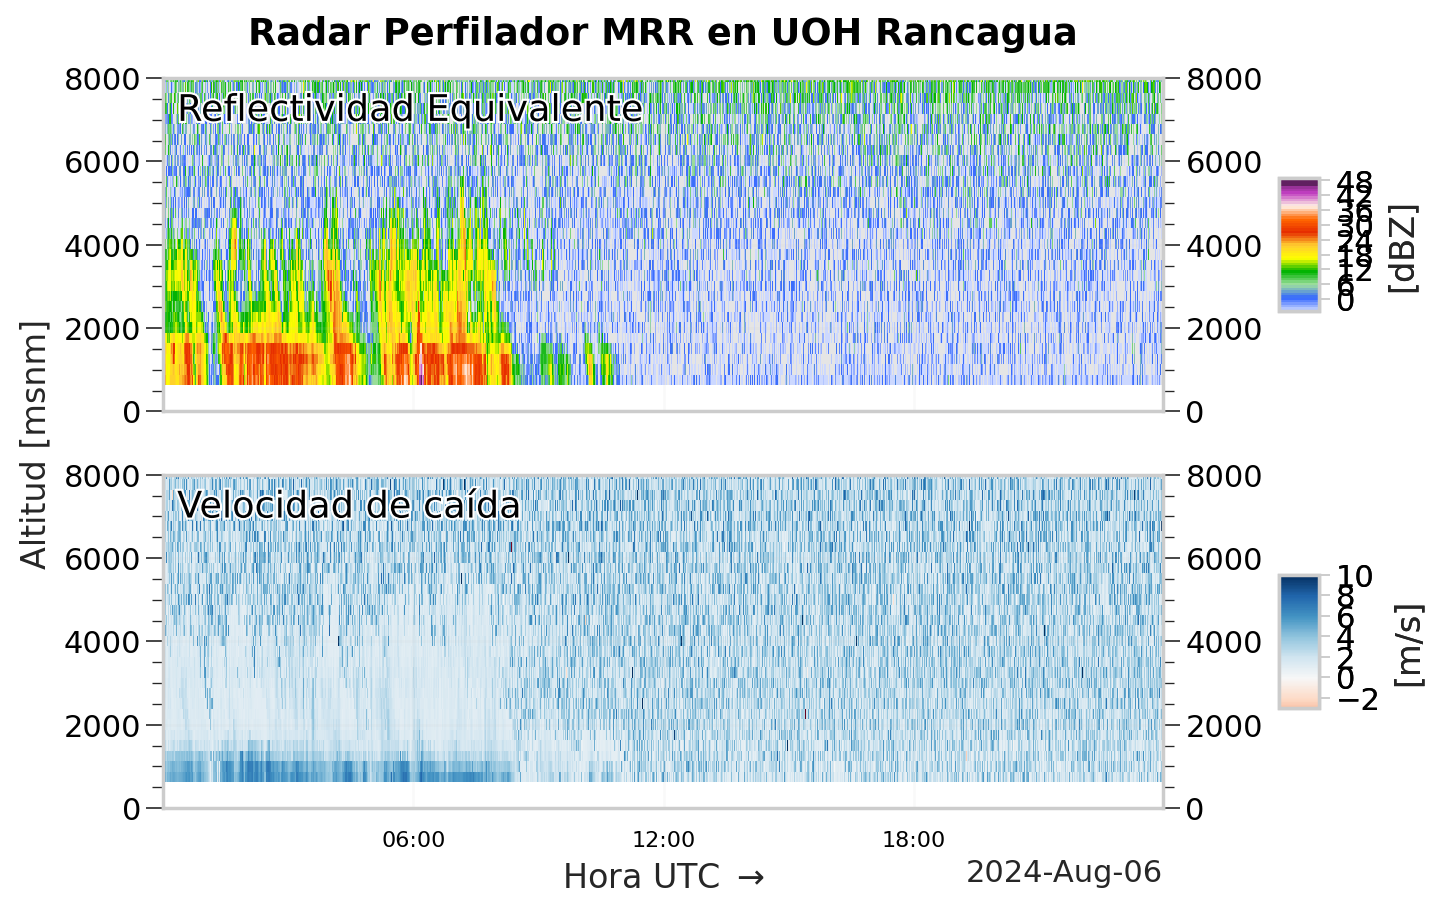

In [14]:
new_time = pd.to_datetime(ds.time.values)
xlim = [new_time[0], new_time[-1]]
heights = ds.height[0,:]+500
Ze = ds['attenuated_radar_reflectivity']
Vf = ds['fall_velocity']

plot_mrr2(xlim,pd.to_datetime(ds.time.values) , heights, Ze, Vf, hora_local=False)


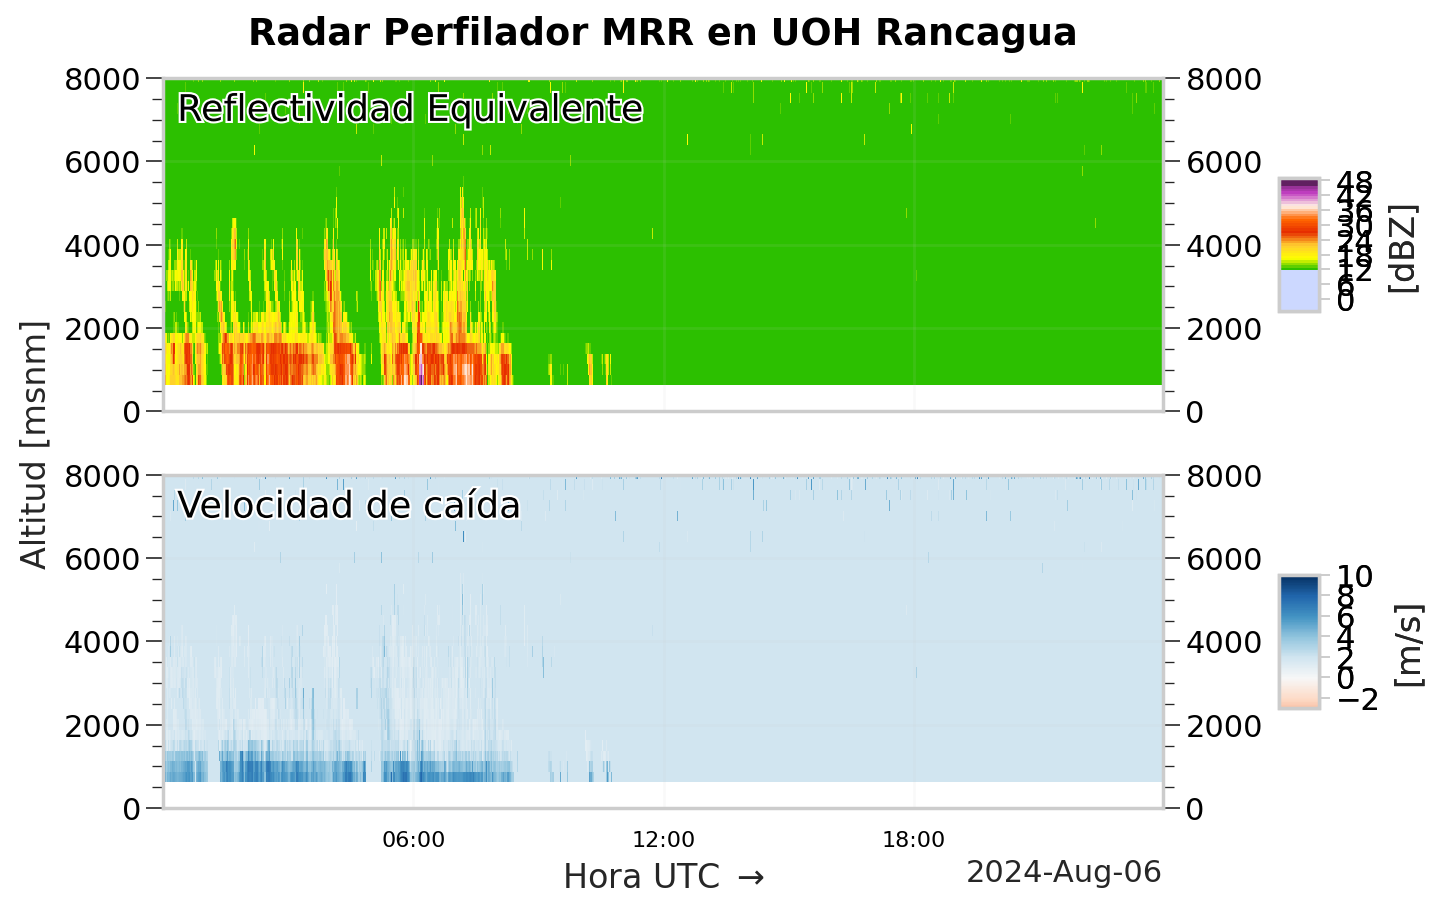

In [15]:
Ze_filtered, Vf_filtered = ruido(Ze, Vf)

plot_mrr2(xlim,pd.to_datetime(ds.time.values) , heights, Ze_filtered, Vf=Vf_filtered, hora_local=False)

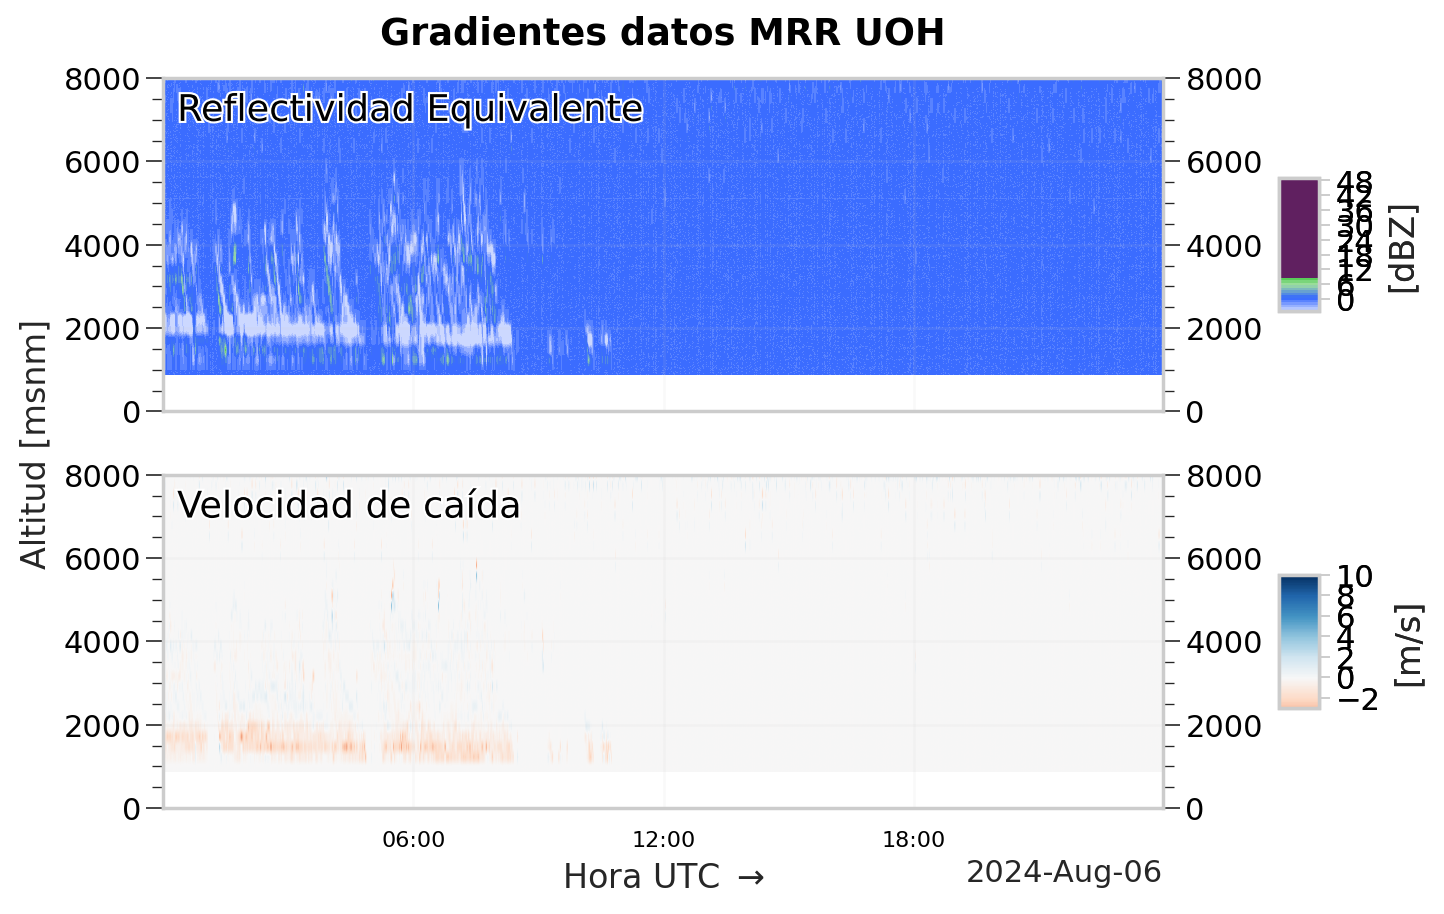

In [16]:
altura_inicial_desfase = 500 + (heights[1] - heights[0]) / 2   # Ajuste altura

heights_ajustado = ds.height[0, :] + altura_inicial_desfase

marco = 1
gradiente_Ze = calcular_gradiente(Ze_filtered.T, marco) #el problema, una vez más era la traspuesta
gradiente_Vf = calcular_gradiente(Vf_filtered.T, marco)
plot_mrr3_imshow(xlim, new_time, heights_ajustado, gradiente_Ze, Vf=gradiente_Vf, hora_local=False)

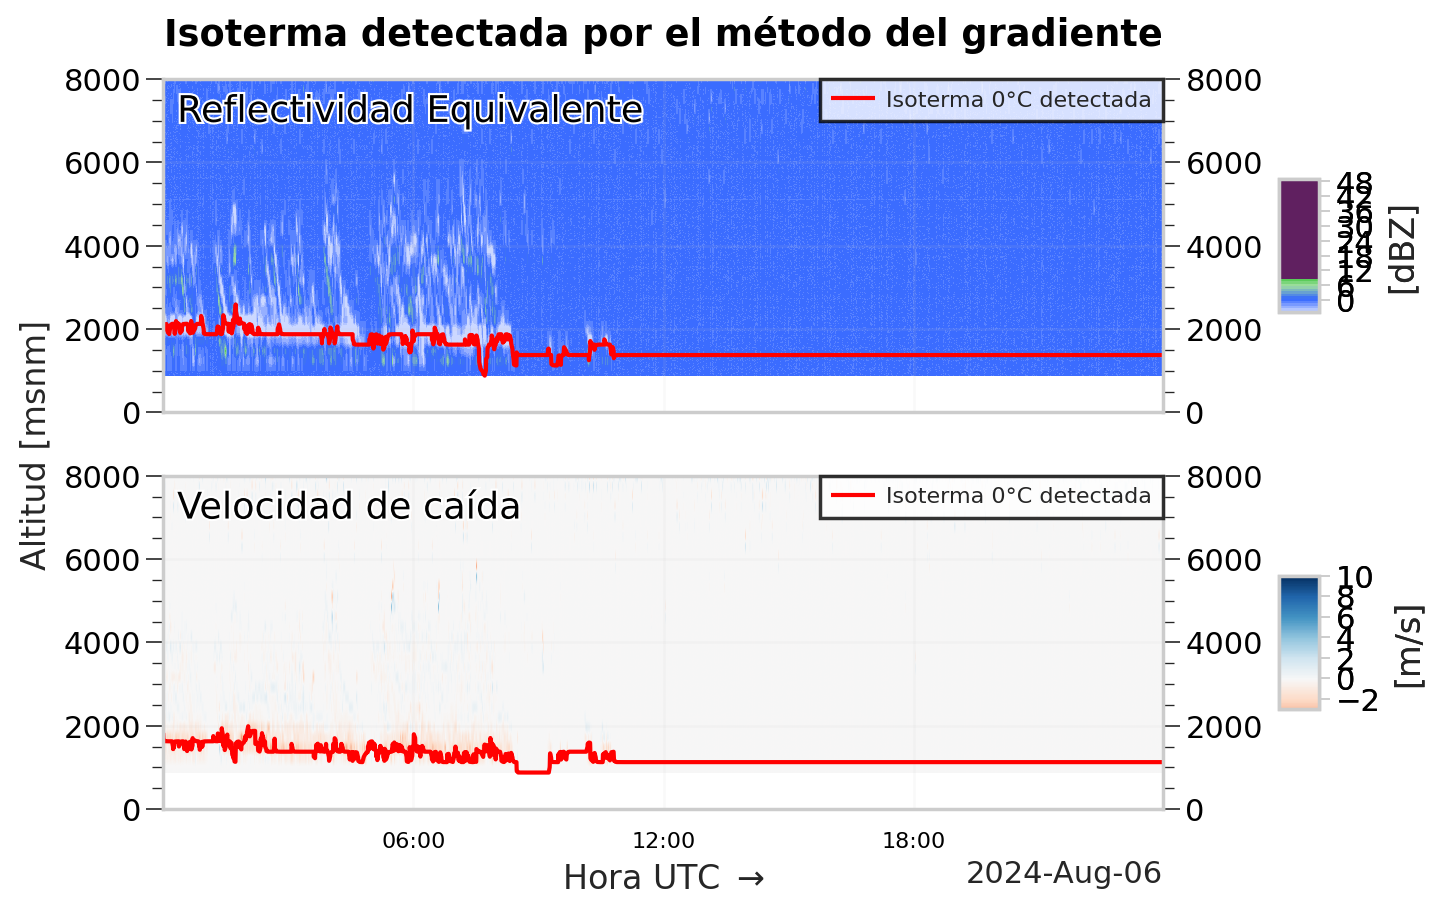

In [17]:
resultados_isoterma_Ze = detectar_isoterma_cero(gradiente_Ze, altura_inicial=2000, heights_ajustado=heights_ajustado)
resultados_isoterma_Vf = detectar_isoterma_cero(gradiente_Vf, altura_inicial=2000, heights_ajustado=heights_ajustado)

# Graficar con la isoterma
plot_mrr3_imshow_con_isoterma(xlim, new_time, heights_ajustado, gradiente_Ze, resultados_isoterma_Ze, Vf=gradiente_Vf, isoterma_results_Vf=resultados_isoterma_Vf)